In [2]:
import json
import os
import glob
import pandas as pd
from Bio.Seq import Seq
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
import seaborn as sns

## compare dA/dt, dN/dt and dS/dt between human and avian H1 and H3

In [1]:
avian_lineages = ['H1a', 'H1b', 'H3a', 'H3b', 'H3c']

In [3]:
# read in nonsyn and syn rates (avian calculated in `calc_avain_dNdt_and_dSdt.ipynb`)
# human rates calculated for a different project, results copied here

avian_rates_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/avian_rates_from_ref.tsv', sep='\t')
human_rates_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/human_rates_from_ref.tsv', sep='\t')

In [4]:
# read in adaptation results

human_adaptation_df = pd.read_csv(f'Supplement-AvianHArates/rates_results/human_full_spikeHA_adaptation_rates.tsv', sep='\t')


avian_adaptation_results = []
for l in avian_lineages:
    filename = f'Supplement-AvianHArates/adaptation_results/results/avian{l}_ha_3_5_75_adaptation.json'
    with open(filename, 'r') as f:
        adaptation_results = json.load(f)
        avian_adaptation_results.append({'virus': l[:-1], 'lineage': l, 
                                         'gene': 'ha', 
                                         'rate_of_adaptation': adaptation_results['rate_of_adaptation']})
        
avian_adaptation_df = pd.DataFrame(avian_adaptation_results)

In [5]:
legible_names = {'h1n1pdm': 'A/H1N1pdm', 'h3n2': 'A/H3N2', 'vic': 'B/Vic', 'yam': 'B/Yam',
                 'H1a': 'avian H1a', 'H1b': 'avian H1b', 
                 'H3a': 'avian H3a', 'H3b':'avian H3b', 'H3c': 'avian H3c'}

In [6]:
cmap = {'h1n1pdm': '#45b6fe', 'h3n2': '#6C3BAA', 'vic': '#FF4500', 'yam': '#fbba0a',
                 'H1a': '#ceecff', 'H1b': '#ceecff', 
                 'H3a': '#ddcfee', 'H3b':'#ddcfee', 'H3c': '#ddcfee'}

In [7]:
all_viruses= ['h1n1pdm', 'h3n2', 'vic', 'yam', 'H1a', 'H1b', 'H3a', 'H3b', 'H3c']

In [8]:
def plot_human_vs_avian_HA_rate_comparisons(filename=None):
    """
    """
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    to_plot_da_dn_ds = []
        
    for h_virus in ['h1n1pdm', 'h3n2', 'vic', 'yam']:
        virus_df = human_rates_df[human_rates_df['virus']==h_virus]
        ha_df = virus_df[virus_df['gene']=='ha']
        syn_rate = ha_df[ha_df['mut_type']=='syn']['rate_per_nt'].item()
        nonsyn_rate = ha_df[ha_df['mut_type']=='nonsyn']['rate_per_nt'].item()
        
        adaptation_rate = human_adaptation_df[human_adaptation_df['virus']==h_virus]['adaptation_rate'].item()

        to_plot_da_dn_ds.append({'virus': h_virus, 'host': 'human', 
                              'ha_syn_rate': syn_rate, 'ha_nonsyn_rate': nonsyn_rate, 
                                 'ha_adaptation_rate': adaptation_rate})
        
    for a_virus in ['H1a', 'H1b', 'H3a', 'H3b', 'H3c']:
        virus_df = avian_rates_df[avian_rates_df['virus']==f'avian{a_virus}']
        ha_df = virus_df[virus_df['gene']=='ha']
        syn_rate = ha_df[ha_df['mut_type']=='syn']['rate_per_nt'].item()
        nonsyn_rate = ha_df[ha_df['mut_type']=='nonsyn']['rate_per_nt'].item()
        
        adaptation_rate = avian_adaptation_df[avian_adaptation_df['lineage']==a_virus]['rate_of_adaptation'].item()

        to_plot_da_dn_ds.append({'virus': a_virus, 'host': 'avian', 
                              'ha_syn_rate': syn_rate, 'ha_nonsyn_rate': nonsyn_rate, 
                                 'ha_adaptation_rate':adaptation_rate})
        
    
    da_dn_ds_df = pd.DataFrame(to_plot_da_dn_ds)
    
    #plot styling
    sns.set_style("white")
    plt.rcParams['figure.dpi']= 300
    plt.rcParams['font.family'] = 'Arial'
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4))
    
    for v in all_viruses:
        leg_name = legible_names[v]

        df_v = da_dn_ds_df[da_dn_ds_df['virus']==v]
        ax1.scatter(y=df_v['ha_nonsyn_rate'], x=df_v['ha_syn_rate'], s=80, color=cmap[v])

        ax1.annotate(leg_name, (df_v['ha_syn_rate']+0.0001+manual_adjustments_v['x'][v], 
                         df_v['ha_nonsyn_rate']-0.000005+manual_adjustments_v['y'][v]), 
                     fontsize=8) 


        ax2.scatter(x=df_v['ha_nonsyn_rate'], y= df_v['ha_adaptation_rate'], s=80, color=cmap[v])
        if v in ['H3a']:
            ax2.annotate(
                leg_name,
                xy=(df_v['ha_nonsyn_rate'], df_v['ha_adaptation_rate'] + 0.00005),  # point to annotate
                xytext=(
                    df_v['ha_nonsyn_rate'] + manual_adjustments_va['x'][v],
                    df_v['ha_adaptation_rate'] + manual_adjustments_va['y'][v]
                ),  # location of text
                fontsize=8,
                arrowprops=dict(arrowstyle="-", color="black", lw=0.5)  # line from point to text
            )
        else:
            ax2.annotate(leg_name, (df_v['ha_nonsyn_rate']+0.00008+manual_adjustments_va['x'][v], 
                             df_v['ha_adaptation_rate']-0.000006+manual_adjustments_va['y'][v]), 
                         fontsize=8) 
            

    # figure panel labels
    ax1.text(-0.35, 0.98, 'A', fontsize=16, transform=ax1.transAxes) 

    ax2.text(-0.3, 0.98, 'B', fontsize=16, transform=ax2.transAxes) 
    
    # axis labels
    ax1.set_ylabel('HA dN/dt')
    ax1.set_xlabel('HA dS/dt')
    ax2.set_xlabel('HA dN/dt')
    ax2.set_ylabel('HA dA/dt')
    
    # add a legend
    ax1.legend(handles=[Line2D([0], [0], marker='o', color='w', label='Human',
                               markerfacecolor='#808080', markersize=10), 
                        Line2D([0], [0], marker='o', color='w', label='Avian',
                               markerfacecolor='#d3d3d3', markersize=10)],
              bbox_to_anchor=(0.45,0.98), fontsize=8,title_fontsize=8, title = 'Viral host species', 
               bbox_transform = ax1.transAxes)
    
    
    fig.subplots_adjust(wspace=0.4)



    sns.despine()
    
    if filename:
        fig.savefig(filename, dpi=300, bbox_inches='tight')

In [9]:
manual_adjustments_v = {'x': {v:0.0 for v in all_viruses}, 
                        'y': {v:0.0 for v in all_viruses}}
manual_adjustments_va = {'x': {v:0.0 for v in all_viruses}, 
                        'y': {v:0.0 for v in all_viruses}}

manual_adjustments_v['x']['H1a'] = -0.00025
manual_adjustments_v['y']['H1a'] = -0.00012
manual_adjustments_v['x']['H1b'] = -0.00025
manual_adjustments_v['y']['H1b'] = -0.00012
manual_adjustments_v['x']['H3c'] = -0.00025
manual_adjustments_v['y']['H3c'] = 0.0001

manual_adjustments_va['y']['H1a'] = -0.00008
manual_adjustments_va['y']['H1b'] = 0.00003
manual_adjustments_va['y']['H3b'] = -0.00008
manual_adjustments_va['y']['H3a'] = 0.0004
manual_adjustments_va['y']['H3c'] = -0.00003
manual_adjustments_va['x']['H3a'] = -0.00008


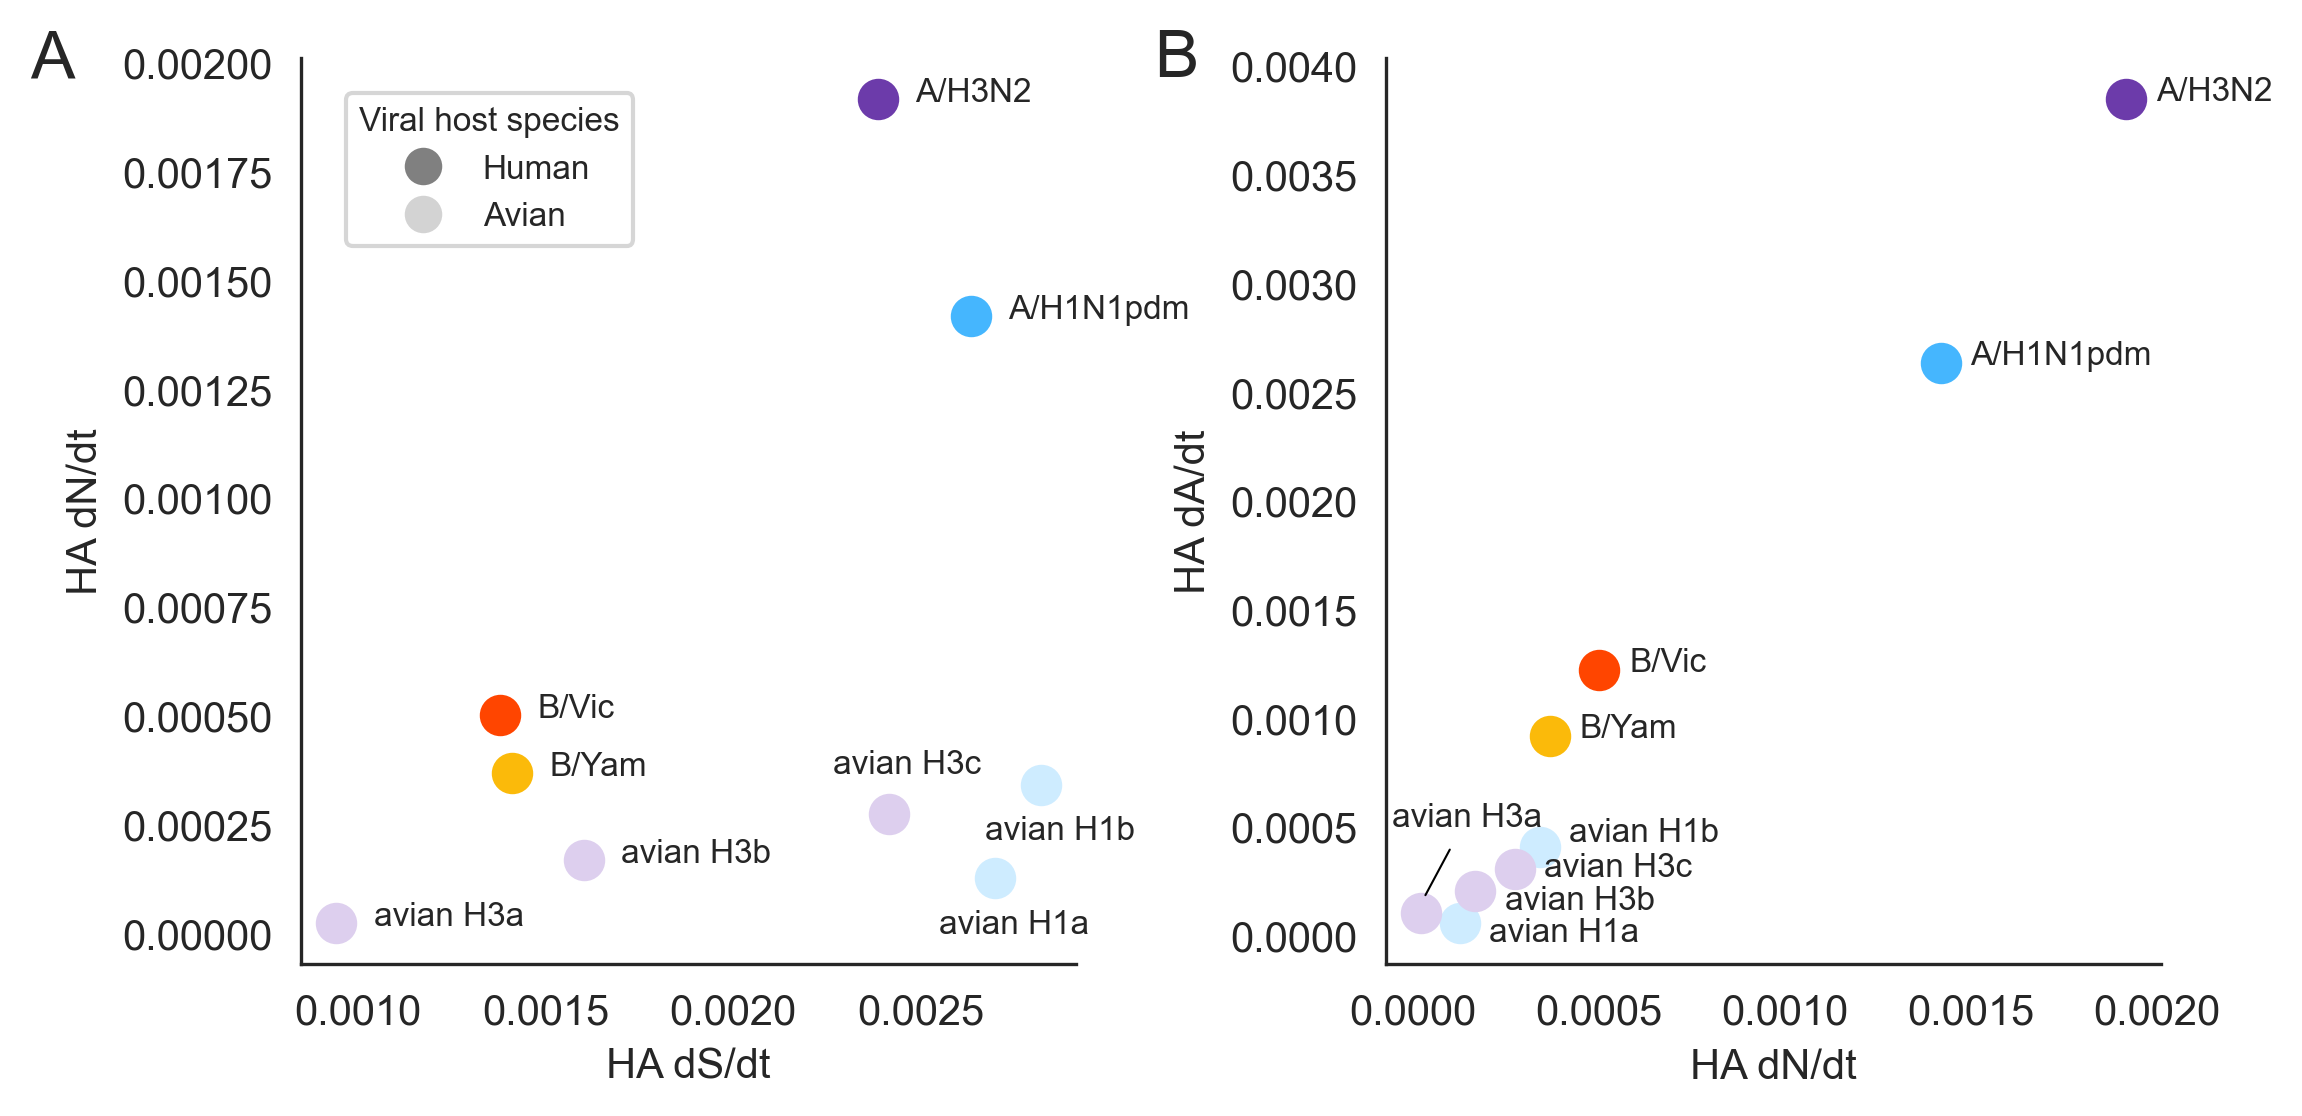

In [12]:
plot_human_vs_avian_HA_rate_comparisons(filename = 'Supplement-AvianHArates/human_vs_avian_rates.png')